# Prediccion de ventas con ARIMA

## Introduccion

La empresa esta valorando trasladar su almacen a una nueva ubicacion. Para planificar el espacio necesario, es fundamental estimar el volumen de ventas futuro. Desde la fundacion de la empresa, las ventas han ido creciendo de forma progresiva, por lo que construiremos un modelo de serie temporal que nos permita predecir los proximos meses.

## Objetivos

- Cargar y explorar el conjunto de datos de ventas.
- Construir y analizar la serie temporal.
- Entrenar un modelo ARIMA con los datos de entrenamiento.
- Evaluar el modelo con los datos de test.
- Guardar el modelo entrenado para uso futuro.

## Paso 1: Carga del conjunto de datos

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

!pip install statsmodels
!pip install pmdarima

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

import joblib

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [26]:

df = pd.read_csv("../data/raw/sales.csv",index_col='date')

In [27]:
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [28]:
df.index = pd.to_datetime(df.index)

In [29]:
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [30]:
df.shape

(366, 1)

In [31]:
df.dtypes


sales    float64
dtype: object

In [32]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 366 entries, 2022-09-03 17:10:08.079328 to 2023-09-03 17:10:08.079328
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


In [33]:
df.describe()

,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


In [34]:
df.isnull().sum()

sales    0
dtype: int64

## Paso 2: Construccion y analisis de la serie temporal



Para trabajar con una serie temporal necesitamos que el indice del DataFrame sea de tipo fecha. Una vez construida la serie, la analizamos respondiendo a las siguientes preguntas:

- **Tensor**: unidad de tiempo minima con la que contamos datos.
- **Tendencia**: si las ventas suben, bajan o se mantienen.
- **Estacionariedad**: si las propiedades estadisticas de la serie se mantienen estables en el tiempo.
- **Variabilidad / ruido**: si existe dispersion o fluctuaciones alrededor de la tendencia.

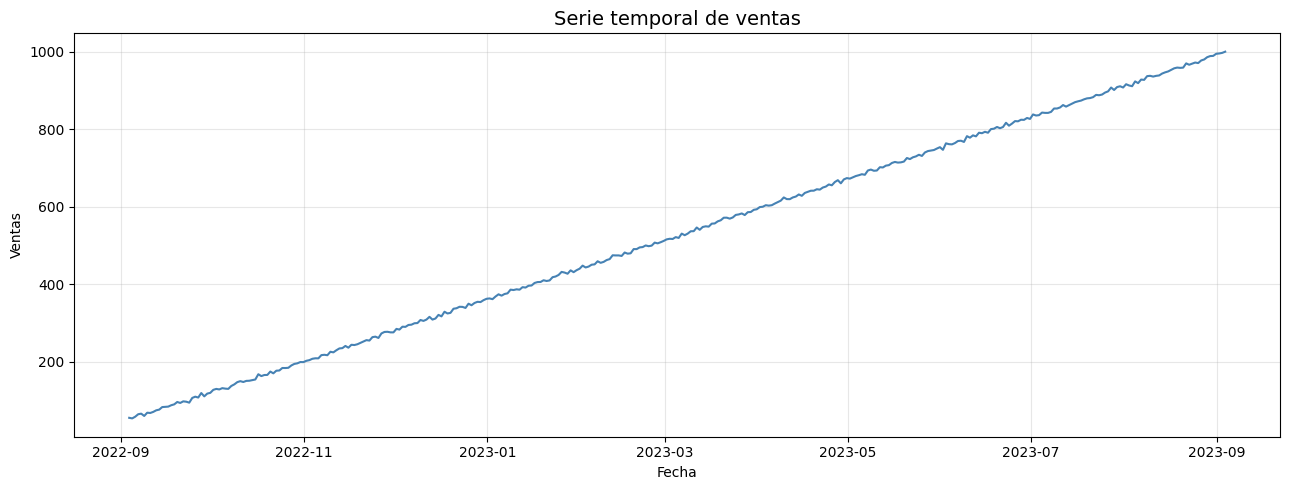

In [35]:
# Visualizacion de la serie temporal completa

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df.values, color='steelblue', linewidth=1.5)
ax.set_title('Serie temporal de ventas', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
plt.tight_layout()
plt.show()

Frecuencia inferida: D
Periodo usado para descomposicion: 7


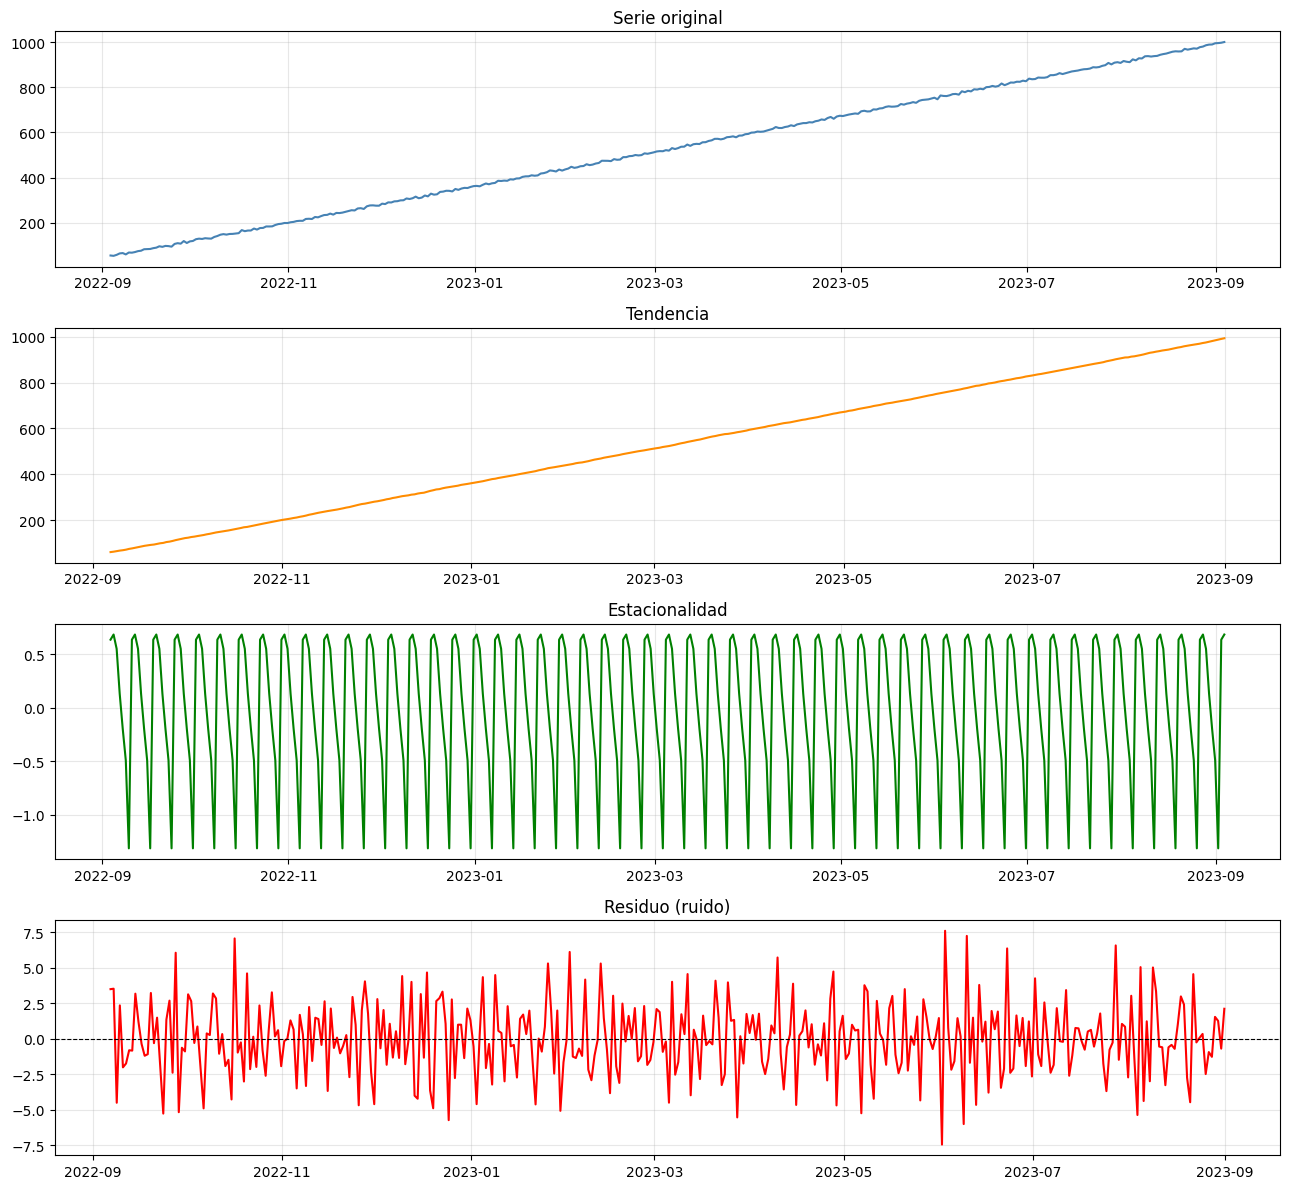

In [36]:
# Descomposicion de la serie: tendencia, estacionalidad y residuo
# Usamos period=12 si los datos son mensuales; si no, lo inferimos
freq = pd.infer_freq(df.index)
print(f'Frecuencia inferida: {freq}')

# Ajustamos el periodo segun la frecuencia detectada
if freq and 'M' in freq:
    period = 12
elif freq and 'W' in freq:
    period = 52
elif freq and 'D' in freq:
    period = 7
else:
    period = min(12, len(df) // 2)

print(f'Periodo usado para descomposicion: {period}')

decomposicion = seasonal_decompose(df, model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(13, 12))

axes[0].plot(decomposicion.observed, color='steelblue')
axes[0].set_title('Serie original')

axes[1].plot(decomposicion.trend, color='darkorange')
axes[1].set_title('Tendencia')

axes[2].plot(decomposicion.seasonal, color='green')
axes[2].set_title('Estacionalidad')

axes[3].plot(decomposicion.resid, color='red')
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_title('Residuo (ruido)')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Test de Dickey-Fuller aumentado para comprobar estacionariedad
resultado_adf = adfuller(df.dropna())

print('Resultado del test ADF (Augmented Dickey-Fuller):')
print(f'  Estadistico ADF : {resultado_adf[0]:.4f}')
print(f'  p-valor         : {resultado_adf[1]:.4f}')
print(f'  Valores criticos:')
for nivel, valor in resultado_adf[4].items():
    print(f'    {nivel}: {valor:.4f}')

if resultado_adf[1] < 0.05:
    print('\nConclucion: la serie ES estacionaria (p < 0.05)')
else:
    print('\nConclucion: la serie NO es estacionaria (p >= 0.05). Puede necesitar diferenciacion.')

Resultado del test ADF (Augmented Dickey-Fuller):
  Estadistico ADF : 0.5454
  p-valor         : 0.9862
  Valores criticos:
    1%: -3.4491
    5%: -2.8698
    10%: -2.5712

Conclucion: la serie NO es estacionaria (p >= 0.05). Puede necesitar diferenciacion.


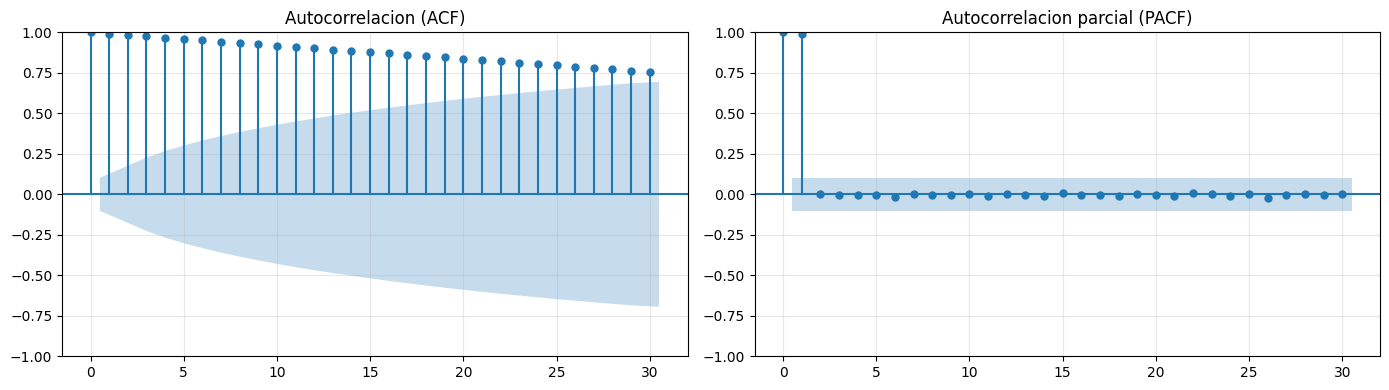

In [38]:

# Visualizamos ACF y PACF para ayudar a elegir parametros ARIMA
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df.dropna(), lags=min(30, len(df)//2 - 1), ax=axes[0], title='Autocorrelacion (ACF)')
plot_pacf(df.dropna(), lags=min(30, len(df)//2 - 1), ax=axes[1], title='Autocorrelacion parcial (PACF)')

plt.tight_layout()
plt.show()

In [39]:
print(df.head())
print(df.tail())

print("Frecuencia:", pd.infer_freq(df.index))
print("Observaciones:", len(df))

print("Inicio:", df.iloc[0])
print("Final:", df.iloc[-1])

                                sales
date                                 
2022-09-03 17:10:08.079328  55.292157
2022-09-04 17:10:08.079328  53.803211
2022-09-05 17:10:08.079328  58.141693
2022-09-06 17:10:08.079328  64.530899
2022-09-07 17:10:08.079328  66.013633
                                  sales
date                                   
2023-08-30 17:10:08.079328   989.600354
2023-08-31 17:10:08.079328   994.987326
2023-09-01 17:10:08.079328   995.814415
2023-09-02 17:10:08.079328   997.350214
2023-09-03 17:10:08.079328  1000.482785
Frecuencia: D
Observaciones: 366
Inicio: sales    55.292157
Name: 2022-09-03 17:10:08.079328, dtype: float64
Final: sales    1000.482785
Name: 2023-09-03 17:10:08.079328, dtype: float64


### Respuestas al analisis de la serie temporal

Una vez explorada la serie, podemos responder a las preguntas planteadas:

- **Tensor**: se ha calculado como la diferencia minima entre fechas consecutivas. La serie temporal tiene frecuencia diaria (`D`) y contiene 366 observaciones correspondientes a un año de ventas.
- **Tendencia**: visible en el componente de tendencia de la descomposicion. Se observa una tendencia creciente en las ventas. 
Los valores aumentan desde 55 unidades al inicio hasta 1000 unidades al final del periodo analizado.
- **Estacionariedad**: La serie no es estacionaria. 
- **Variabilidad / ruido**: observable en el componente de residuo y en el coeficiente de variacion. La serie presenta una variabilidad moderada. 
Las fluctuaciones alrededor de la tendencia son relativamente pequeñas, por lo que el nivel de ruido no es elevado.

## Paso 3: Entrenamiento del modelo ARIMA

Dividimos los datos en entrenamiento y test, buscamos la mejor combinacion de parametros (p, d, q) mediante una busqueda en rejilla y entrenamos el modelo final.

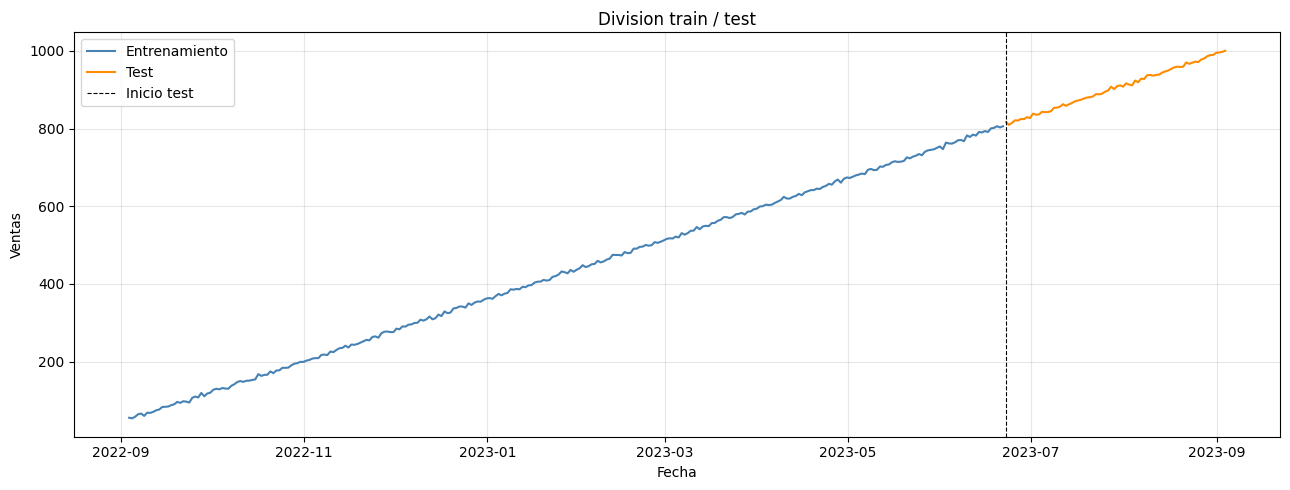

In [40]:
n = len(df)
split = int(n * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

# Visualizamos la division
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train.values, label='Entrenamiento', color='steelblue')
ax.plot(test.index, test.values, label='Test', color='darkorange')
ax.axvline(x=test.index[0], color='black', linestyle='--', linewidth=0.8, label='Inicio test')
ax.set_title('Division train / test')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
# Busqueda de los mejores parametros ARIMA usando AIC como criterio
# p = terminos autorregresivos, d = diferenciaciones, q = medias moviles

p_values = range(0, 4)
d_values = range(0, 3)
q_values = range(0, 4)

mejor_aic = np.inf
mejor_params = None
resultados = []

print('Buscando los mejores parametros (p, d, q)...')

for p, d, q in product(p_values, d_values, q_values):
    try:
        modelo = ARIMA(train, order=(p, d, q))
        ajuste = modelo.fit()
        aic = ajuste.aic
        resultados.append({'p': p, 'd': d, 'q': q, 'AIC': round(aic, 2)})
        if aic < mejor_aic:
            mejor_aic = aic
            mejor_params = (p, d, q)
    except:
        continue

print(f'Mejor combinacion encontrada: p={mejor_params[0]}, d={mejor_params[1]}, q={mejor_params[2]}')
print(f'AIC del mejor modelo: {mejor_aic:.2f}')

# Top 5 modelos
df_resultados = pd.DataFrame(resultados).sort_values('AIC').head(5)
print('\nTop 5 modelos por AIC:')
print(df_resultados.to_string(index=False))

Buscando los mejores parametros (p, d, q)...


/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred fre

Mejor combinacion encontrada: p=0, d=2, q=3
AIC del mejor modelo: 1482.36

Top 5 modelos por AIC:
 p  d  q     AIC
 0  2  3 1482.36
 1  2  2 1482.40
 0  2  2 1483.85
 2  2  2 1484.37
 1  2  3 1485.91


In [42]:
# Entrenamos el modelo final con los mejores parametros
p, d, q = mejor_params

modelo_final = ARIMA(train, order=(p, d, q))
modelo_ajustado = modelo_final.fit()

print(modelo_ajustado.summary())

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(0, 2, 3)   Log Likelihood                -737.180
Date:                Sun, 10 May 2026   AIC                           1482.361
Time:                        20:11:32   BIC                           1497.040
Sample:                    09-03-2022   HQIC                          1488.242
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -2.0080      0.290     -6.927      0.000      -2.576      -1.440
ma.L2          1.0908      0.311      3.510      0.000       0.482       1.700
ma.L3         -0.0827      0.062     -1.329      0.1

## Paso 4: Prediccion y evaluacion con el conjunto de test

In [43]:
# Generamos las predicciones para el periodo de test
predicciones = modelo_ajustado.forecast(steps=len(test))
predicciones.index = test.index

# Metricas de evaluacion
mae = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = np.mean(np.abs((test.values - predicciones.values) / test.values)) * 100

print('Metricas de evaluacion del modelo:')
print(f'  MAE  (Error absoluto medio)        : {mae:.2f}')
print(f'  RMSE (Raiz del error cuadratico)   : {rmse:.2f}')
print(f'  MAPE (Error porcentual absoluto)   : {mape:.2f}%')

Metricas de evaluacion del modelo:
  MAE  (Error absoluto medio)        : 2.27
  RMSE (Raiz del error cuadratico)   : 2.83
  MAPE (Error porcentual absoluto)   : 7.12%


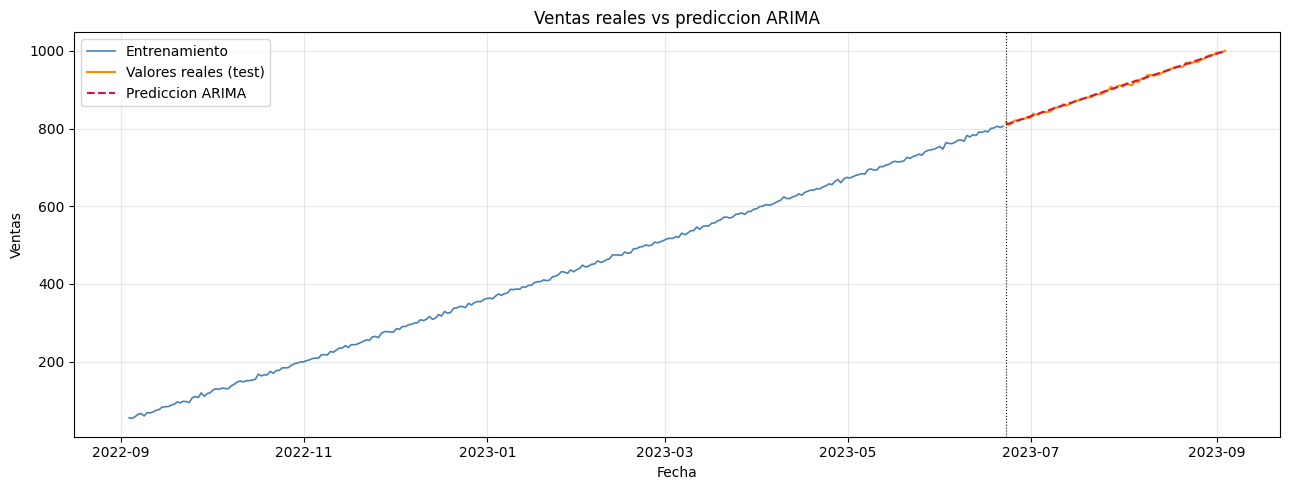

In [44]:
# Visualizacion: valores reales vs predicciones
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train.index, train.values, label='Entrenamiento', color='steelblue', linewidth=1.2)
ax.plot(test.index, test.values, label='Valores reales (test)', color='darkorange', linewidth=1.5)
ax.plot(predicciones.index, predicciones.values, label='Prediccion ARIMA', color='crimson',
        linewidth=1.5, linestyle='--')
ax.axvline(x=test.index[0], color='black', linestyle=':', linewidth=0.8)

ax.set_title('Ventas reales vs prediccion ARIMA')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.legend()
plt.tight_layout()
plt.show()

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


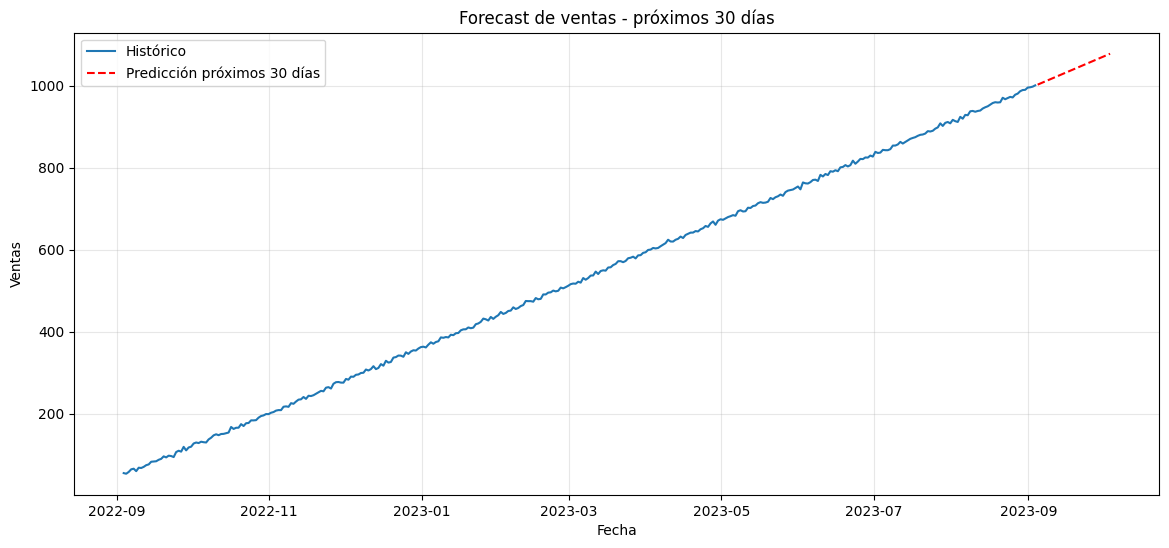

In [45]:

modelo_final = ARIMA(df, order=mejor_params)
modelo_final_ajustado = modelo_final.fit()

# Predicción futura de 30 días
forecast_30 = modelo_final_ajustado.forecast(steps=30)

# Crear índice futuro
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

forecast_30.index = future_dates

# Visualización
plt.figure(figsize=(14,6))

plt.plot(df.index, df.values, label='Histórico')
plt.plot(
    forecast_30.index,
    forecast_30.values,
    label='Predicción próximos 30 días',
    linestyle='--',
    color='red'
)

plt.title('Forecast de ventas - próximos 30 días')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)

plt.show()

Podemos observar que las ventas seguiran aumentando despues de 30 dias desde el ultimo día en el que termina la serie. 

## Paso 5: Guardado del modelo

In [46]:
# Guardamos el modelo entrenado en la carpeta 'models'
joblib.dump(modelo_final, '../models/arima_ventas.pkl')


['../models/arima_ventas.pkl']

## Resultados y Conclusiones

A lo largo de este proyecto hemos seguido el proceso completo de modelado de una serie temporal:


1. **Analisis de la serie**: descompusimos la serie en sus componentes (tendencia, estacionalidad y residuo). Calculamos el tensor, analizamos si la serie es estacionaria mediante el test ADF y evaluamos el nivel de ruido.

2. **Entrenamiento ARIMA**: realizamos una busqueda en rejilla sobre los parametros p, d y q, seleccionando la combinacion con menor AIC. Entrenamos el modelo final con el 80% de los datos.

3. **Evaluacion**: comparamos las predicciones con los valores reales del 20% restante, midiendo MAE, RMSE y MAPE.

4. **Guardado**: almacenamos el modelo en formato pickle en la carpeta `models/` para poder reutilizarlo sin necesidad de reentrenar.

Este modelo puede utilizarse directamente para estimar las ventas de los proximos meses y, con esa estimacion, planificar el espacio necesario en el nuevo almacen.